# Ejercicios de NumPy, Pandas y Matplotlib

Este cuaderno contiene 10 ejercicios prácticos que combinan NumPy, Pandas y Matplotlib.  
Rellena cada celda de código con tu solución.

## Ejercicio 1 — Carga y exploración inicial (Pandas)

Carga un archivo CSV llamado **`mediciones_industriales.csv`** que contiene 8.000 registros y las columnas:  
`ID`, `Presion`, `Caudal`, `Vibracion`, `Estado`.

1. Muestra las **primeras 7 filas** del DataFrame.  
2. Muestra el **tipo de datos** de cada columna.  
3. Indica cuántos **valores nulos** hay por columna.

In [6]:
# Importamos las librerías necesarias
import pandas as pd      # Pandas para trabajar con DataFrames
import numpy as np       # NumPy para operaciones numéricas

# Cargamos el archivo CSV en un DataFrame llamado df
df = pd.read_csv("mediciones_industriales.csv")   # Lee el archivo CSV y crea el DataFrame

# Mostramos las primeras 7 filas del DataFrame
print("Primeras 7 filas:")   # Mensaje informativo
display(df.head(7))          # head(7) muestra las primeras 7 filas

# Mostramos los tipos de datos de cada columna
print("\nTipos de datos:")   # \n añade una línea en blanco para separar secciones
print(df.dtypes)             # dtypes muestra el tipo de dato de cada columna

# Contamos cuántos valores nulos hay por columna
print("\nValores nulos por columna:")  # Mensaje informativo
print(df.isna().sum())                 # isna() detecta nulos y sum() los cuenta por columna

Primeras 7 filas:


,ID,Presion,Caudal,Vibracion,Estado
0,1,103.07,75.91,6.47,Normal
1,2,92.17,25.59,7.16,Normal
2,3,91.95,42.66,6.38,Normal
3,4,98.35,76.93,2.94,Normal
4,5,105.28,23.34,4.17,Normal
5,6,101.67,10.42,2.82,Normal
6,7,87.42,44.11,4.26,Normal



Tipos de datos:
ID             int64
Presion      float64
Caudal       float64
Vibracion    float64
Estado        object
dtype: object

Valores nulos por columna:
ID           0
Presion      0
Caudal       0
Vibracion    0
Estado       0
dtype: int64


## Ejercicio 2 — Creación de Series y detección de nulos

Crea una **Serie** con los valores:

[101.2, 98.7, NaN, 105.3, 100.1]

y el índice:

["A", "B", "C", "D", "E"]

1. Muestra la serie completa.  
2. Usa `pd.isna()` y `pd.notna()` para identificar valores faltantes.  
3. Asigna un nombre a la serie y al índice.

In [7]:
# Creamos una lista con valores numéricos, incluyendo un NaN (valor faltante)
valores = [101.2, 98.7, np.nan, 105.3, 100.1]   # np.nan representa un dato ausente

# Creamos una lista con los índices que usará la Serie
indices = ["A", "B", "C", "D", "E"]             # Etiquetas personalizadas para cada valor

# Construimos la Serie de Pandas usando los valores y los índices definidos
serie = pd.Series(valores, index=indices)       # Crea la Serie con índice personalizado

# Asignamos un nombre a la Serie y al índice
serie.name = "Presion"                          # Nombre de la Serie
serie.index.name = "Muestras"                   # Nombre del índice

# Mostramos la Serie completa
print("Serie:")                                 # Mensaje informativo
display(serie)                                  # Muestra la Serie en formato tabla

# Identificamos los valores faltantes (NaN)
print("\nValores faltantes:")                   # \n añade una línea en blanco
display(pd.isna(serie))                         # True donde hay NaN, False en el resto

# Identificamos los valores no nulos
print("\nValores no nulos:")                    # Mensaje informativo
display(pd.notna(serie))                        # True donde hay datos válidos

Serie:


Muestras
A    101.2
B     98.7
C      NaN
D    105.3
E    100.1
Name: Presion, dtype: float64


Valores faltantes:


Muestras
A    False
B    False
C     True
D    False
E    False
Name: Presion, dtype: bool


Valores no nulos:


Muestras
A     True
B     True
C    False
D     True
E     True
Name: Presion, dtype: bool

## Ejercicio 3 — Construcción de DataFrame desde diccionarios

Crea un DataFrame a partir del siguiente diccionario anidado:


In [ ]:
produccion = { "Planta_A": {2020: 1200, 2021: 1350, 2022: 1400}, "Planta_B": {2020: 900, 2021: 1100, 2022: 1150} }

1. Muestra el DataFrame.  
2. Añade una columna `"Diferencia"` = Planta_A - Planta_B.  
3. Indica si el índice del DataFrame es único.

In [8]:
# Diccionario anidado con la producción anual de dos plantas
produccion = {
    "Planta_A": {2020: 1200, 2021: 1350, 2022: 1400},   # Producción de Planta A por año
    "Planta_B": {2020: 900, 2021: 1100, 2022: 1150}     # Producción de Planta B por año
}

# Convertimos el diccionario en un DataFrame de Pandas
df_prod = pd.DataFrame(produccion)   # Las claves externas serán columnas y los años serán el índice

# Creamos una nueva columna calculando la diferencia entre ambas plantas
df_prod["Diferencia"] = df_prod["Planta_A"] - df_prod["Planta_B"]   # Resta vectorizada

# Mostramos el DataFrame resultante
print("DataFrame de producción:")   # Mensaje informativo
display(df_prod)                    # Visualización en formato tabla

# Comprobamos si el índice del DataFrame es único
print("\n¿Índice único?:", df_prod.index.is_unique)   # Devuelve True si no hay índices duplicados

DataFrame de producción:


,Planta_A,Planta_B,Diferencia
2020,1200,900,300
2021,1350,1100,250
2022,1400,1150,250



¿Índice único?: True


## Ejercicio 4 — Estadística descriptiva con NumPy

Dado el siguiente array:

vibracion = np.random.normal(5, 1.2, 5000)


1. Calcula media, mediana, varianza y desviación estándar.  
2. Calcula los percentiles 10, 50 y 90.  
3. Explica si la distribución parece simétrica o asimétrica.


In [9]:
# Generamos un array de 5000 valores siguiendo una distribución normal
# Media teórica = 5, desviación estándar teórica = 1.2
vibracion = np.random.normal(5, 1.2, 5000)

# Cálculos estadísticos básicos con NumPy
media = np.mean(vibracion)          # Calcula la media
mediana = np.median(vibracion)      # Calcula la mediana
varianza = np.var(vibracion)        # Varianza poblacional
desv = np.std(vibracion)            # Desviación estándar poblacional

# Cálculo de percentiles
p10 = np.percentile(vibracion, 10)  # Percentil 10
p50 = np.percentile(vibracion, 50)  # Percentil 50 (equivale a la mediana)
p90 = np.percentile(vibracion, 90)  # Percentil 90

# Mostramos los resultados
print("Media:", round(media, 2))
print("Mediana:", round(mediana, 2))
print("Varianza:", round(varianza, 2))
print("Desviación estándar:", round(desv, 2))

print("\nPercentil 10:", round(p10, 2))
print("Percentil 50:", round(p50, 2))
print("Percentil 90:", round(p90, 2))

# Interpretación de simetría
print("\nInterpretación:")
if abs(media - mediana) < 0.1:      # Si media y mediana son casi iguales
    print("La distribución es aproximadamente simétrica.")
else:
    print("La distribución es asimétrica.")


# -------------------------------------------------------------
# PARTE 2: MISMO ANÁLISIS USANDO PANDAS (describe + quantile)
# -------------------------------------------------------------

# Convertimos el array en una Serie de Pandas
serie_vib = pd.Series(vibracion, name="Vibración")

print("\nResumen estadístico con Pandas (describe):")
display(serie_vib.describe())       # Muestra count, mean, std, min, quartiles y max

# Percentiles adicionales con Pandas
print("\nPercentiles con Pandas:")
print("P10:", serie_vib.quantile(0.10))
print("P50:", serie_vib.quantile(0.50))
print("P90:", serie_vib.quantile(0.90))

Media: 4.99
Mediana: 5.0
Varianza: 1.46
Desviación estándar: 1.21

Percentil 10: 3.44
Percentil 50: 5.0
Percentil 90: 6.54

Interpretación:
La distribución es aproximadamente simétrica.

Resumen estadístico con Pandas (describe):


count    5000.000000
mean        4.994106
std         1.209773
min         0.763663
25%         4.190162
50%         4.998952
75%         5.788519
max         9.186527
Name: Vibración, dtype: float64


Percentiles con Pandas:
P10: 3.4422101799110854
P50: 4.998952069670137
P90: 6.5372757163725


## Ejercicio 5 — Clasificación vectorizada (np.where + Pandas)

Usando la columna `"Caudal"` del DataFrame del ejercicio 1:

Clasifica cada registro en un nuevo array `caudal_clasificado`:

- `< 20` → categoría 1  
- `20–50` → categoría 2  
- `> 50` → categoría 3  

1. Crea el array usando `np.where`.  
2. Añádelo como columna al DataFrame.  
3. Cuenta cuántos registros hay en cada categoría.

In [5]:
# Extraemos la columna "Caudal" del DataFrame como un array de NumPy
caudal = df["Caudal"].values     # .values convierte la Serie en un array numérico

# Clasificación vectorizada usando np.where
caudal_clasificado = np.where(
    caudal < 20, 1,              # Si el caudal es menor que 20 → categoría 1
    np.where(
        caudal <= 50, 2,         # Si está entre 20 y 50 (incluido) → categoría 2
        3                        # Si es mayor que 50 → categoría 3
    )
)

# Añadimos la nueva clasificación como columna del DataFrame
df["Caudal_clasificado"] = caudal_clasificado   # Se agrega la columna al DataFrame original

# Mostramos cuántos registros hay en cada categoría
print("Conteo por categoría:")                   # Mensaje informativo
print(df["Caudal_clasificado"].value_counts())   # Cuenta cuántas veces aparece cada categoría

Conteo por categoría:
Caudal_clasificado
2    3266
3    3124
1    1610
Name: count, dtype: int64


In [11]:
# Aunque np.where funciona, Pandas ofrece una herramienta más específica para clasificar por intervalos: pd.cut()
# Mejora: usar pd.cut para una clasificación más legible, escalable y profesional

df["Caudal_clasificado"] = pd.cut(
    df["Caudal"], 
    bins=[-float('inf'), 20, 50, float('inf')],   # Define los límites de los intervalos: (<20), (20–50], (>50)
    labels=[3, 11, 30]                            # Etiquetas asignadas a cada intervalo en el mismo orden
)

# Mostramos cuántos registros hay en cada categoría
print(df["Caudal_clasificado"].value_counts())    # Cuenta la frecuencia de cada categoría

Caudal_clasificado
11    3266
30    3124
3     1610
Name: count, dtype: int64


## Ejercicio 6 — Slicing y fancy indexing

Usando la columna `"Estado"` del DataFrame:

1. Obtén un array desde el índice 200 al 800 tomando uno de cada 15.  
2. Selecciona mediante fancy indexing los índices `[10, 100, 1000, 3000]`.  
3. Usa indexación booleana para contar cuántos estados son `"Crítico"`.

In [17]:
# La indexación booleana es clave para filtrar registros que cumplen condiciones.

# Extraemos la columna "Estado" como un array de NumPy
estado = df["Estado"].values          # Convierte la Serie en un array de strings

# Slicing: obtenemos elementos desde el índice 200 hasta el 800 (incluido) tomando uno cada 15
slice_estado = estado[200:801:15]     # [inicio:fin_exclusivo:paso]
print("Slice de estados:")
print(slice_estado)

# Fancy indexing: seleccionamos posiciones concretas mediante una lista de índices
fancy = estado[[7, 38]]               # Accede exactamente a los elementos en esas posiciones
print("\nFancy indexing:")
print(fancy)

# Indexación booleana: contamos cuántos registros tienen el estado "Crítico"
criticos = (df["Estado"] == "Crítico").sum()   # Compara y suma los True directamente en el DataFrame
print("\nNúmero de estados 'Crítico':", criticos)

Slice de estados:
['Normal' 'Normal' 'Normal' 'Normal' 'Precaución' 'Normal' 'Precaución'
 'Normal' 'Normal' 'Precaución' 'Precaución' 'Precaución' 'Normal'
 'Normal' 'Normal' 'Normal' 'Normal' 'Normal' 'Crítico' 'Normal' 'Normal'
 'Crítico' 'Normal' 'Precaución' 'Normal' 'Normal' 'Normal' 'Normal'
 'Precaución' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal'
 'Precaución' 'Precaución' 'Normal' 'Precaución' 'Normal' 'Normal']

Fancy indexing:
['Normal' 'Normal']

Número de estados 'Crítico': 776


## Ejercicio 7 — Gráfico de líneas (Matplotlib + Pandas)

Representa la evolución del **Caudal** en los primeros 300 registros:

- Línea roja  
- Grosor 2  
- Título y etiquetas de ejes  
- Cuadrícula activada  

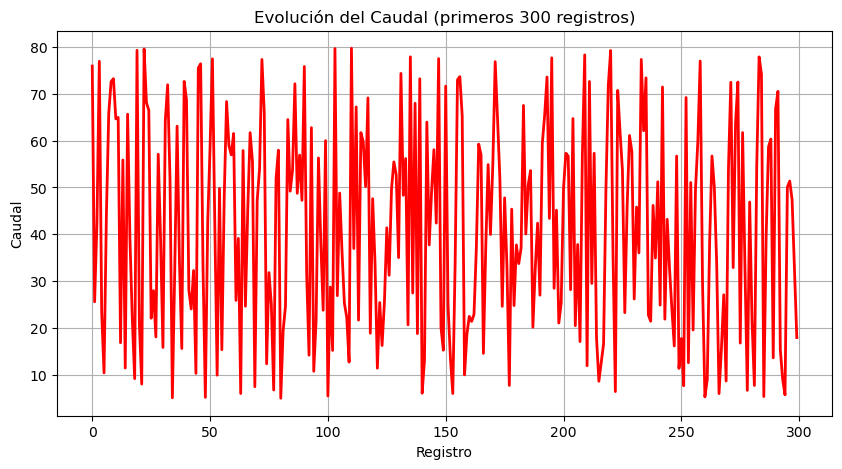

In [18]:
# Importamos la librería de visualización Matplotlib
import matplotlib.pyplot as plt     # Permite crear gráficos de líneas, barras, histogramas, etc.

# Creamos una figura con un tamaño personalizado
plt.figure(figsize=(10,5))          # Ancho = 10 pulgadas, alto = 5 pulgadas

# Dibujamos un gráfico de líneas con los primeros 300 valores de la columna "Caudal"
plt.plot(
    df["Caudal"].head(300),         # Selecciona los primeros 300 registros
    color="red",                    # Color de la línea
    linewidth=2                     # Grosor de la línea
)

# Añadimos título y etiquetas de los ejes
plt.title("Evolución del Caudal (primeros 300 registros)")   # Título del gráfico
plt.xlabel("Registro")                                       # Etiqueta del eje X
plt.ylabel("Caudal")                                         # Etiqueta del eje Y

# Activamos la cuadrícula para facilitar la lectura
plt.grid(True)                       # Muestra líneas de referencia en el fondo

# Mostramos el gráfico en pantalla
plt.show()                           # Renderiza la figura

## Ejercicio 8 — Histograma y análisis

Crea un histograma de la columna `"Presion"` con `bins = 8`.

1. Añade título y etiquetas.  
2. Calcula media, mediana, desviación estándar, percentil 25 y 75.  
3. Explica si el histograma coincide con los valores estadísticos.

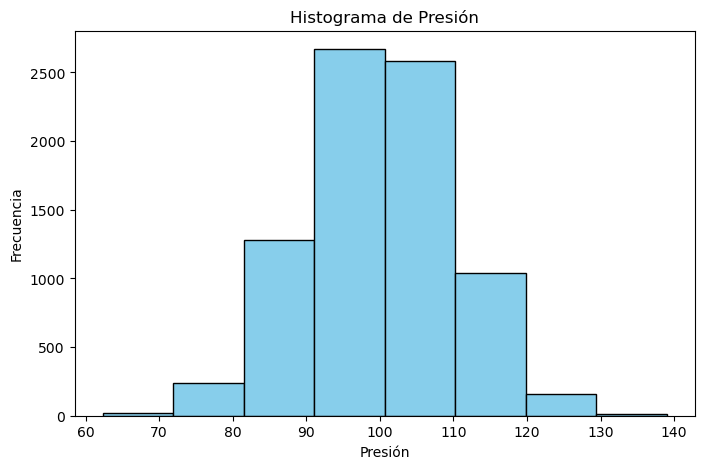

Media: 99.89259125
Mediana: 99.98
Desviación estándar: 9.992430808222066
Percentil 25: 93.0275
Percentil 75: 106.78

Interpretación:
Si la media y la mediana son similares, la distribución es simétrica.


In [19]:
# Creamos una figura para el histograma con un tamaño personalizado
plt.figure(figsize=(8,5))                       # Ancho = 8 pulgadas, alto = 5 pulgadas

# Dibujamos un histograma de la columna "Presion"
plt.hist(
    df["Presion"],                              # Datos a representar
    bins=8,                                      # Número de barras del histograma
    color="skyblue",                             # Color de las barras
    edgecolor="black"                            # Borde negro para mejor visibilidad
)

# Añadimos título y etiquetas de los ejes
plt.title("Histograma de Presión")               # Título del gráfico
plt.xlabel("Presión")                            # Etiqueta del eje X
plt.ylabel("Frecuencia")                         # Etiqueta del eje Y

# Mostramos el gráfico
plt.show()                                       # Renderiza la figura en pantalla

# ---------------------------------------------------------
# Cálculos estadísticos usando Pandas
# ---------------------------------------------------------

pres = df["Presion"]                             # Guardamos la columna en una variable para comodidad

# Mostramos estadísticas básicas
print("Media:", pres.mean())                     # Media aritmética
print("Mediana:", pres.median())                 # Mediana
print("Desviación estándar:", pres.std())        # Desviación estándar muestral
print("Percentil 25:", pres.quantile(0.25))      # Primer cuartil
print("Percentil 75:", pres.quantile(0.75))      # Tercer cuartil

# Interpretación básica de simetría
print("\nInterpretación:")
print("Si la media y la mediana son similares, la distribución es simétrica.")

## Ejercicio 9 — Scatter plot multivariable

Representa un scatter plot con:

- Eje X → `Presion`  
- Eje Y → `Vibracion`  
- Color → `Estado`  
- Solo los primeros 50 registros  
- Colormap `"plasma"`  

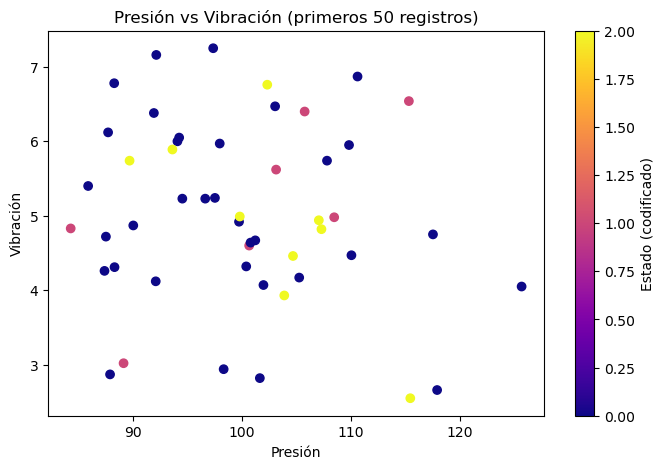

In [20]:
# Scatter plot con codificación de colores según el Estado de cada registro

# Creamos una figura con un tamaño personalizado
plt.figure(figsize=(8,5))                       # Ancho = 8 pulgadas, alto = 5 pulgadas

# Dibujamos un diagrama de dispersión (scatter plot)
plt.scatter(
    df["Presion"].head(50),                     # Eje X: primeros 50 valores de Presión
    df["Vibracion"].head(50),                   # Eje Y: primeros 50 valores de Vibración
    c = pd.factorize(df["Estado"].head(50))[0], # Convierte los estados en códigos numéricos (0,1,2...)
    cmap = "plasma"                             # Mapa de colores elegido
)

# Añadimos título y etiquetas de los ejes
plt.title("Presión vs Vibración (primeros 50 registros)")   # Título del gráfico
plt.xlabel("Presión")                                        # Etiqueta del eje X
plt.ylabel("Vibración")                                      # Etiqueta del eje Y

# Añadimos una barra de color para interpretar los códigos
plt.colorbar(label="Estado (codificado)")       # Muestra la correspondencia entre colores y estados

# Mostramos el gráfico
plt.show()                                       # Renderiza la figura en pantalla

## Ejercicio 10 — Manipulación avanzada de DataFrames

Usando el DataFrame del ejercicio 1:

1. Crea una columna `"Presion_normalizada"` aplicando:  
   (x - min) / (max - min)  
2. Elimina la columna `"Estado"`.  
3. Reordena las columnas para que `"ID"` sea la primera.  
4. Convierte el DataFrame final a un array NumPy con `.to_numpy()`.

In [14]:
df["Presion_normalizada"] = (df["Presion"] - df["Presion"].min()) / (df["Presion"].max() - df["Presion"].min())

df_mod = df.drop(columns=["Estado"])

columnas = ["ID"] + [col for col in df_mod.columns if col != "ID"]
df_mod = df_mod[columnas]

array_final = df_mod.to_numpy()

print("Array final generado correctamente.")
array_final[:5]

Array final generado correctamente.


array([[  1.        , 103.07      ,  75.91      ,   6.47      ,
          3.        ,   0.53132341],
       [  2.        ,  92.17      ,  25.59      ,   7.16      ,
          2.        ,   0.38906291],
       [  3.        ,  91.95      ,  42.66      ,   6.38      ,
          2.        ,   0.38619159],
       [  4.        ,  98.35      ,  76.93      ,   2.94      ,
          3.        ,   0.4697207 ],
       [  5.        , 105.28      ,  23.34      ,   4.17      ,
          2.        ,   0.56016706]])